In [2]:
import sys
print(sys.executable)

c:\Users\Visveswaran\AppData\Local\Programs\Python\Python310\python.exe


In [3]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

conn = sqlite3.connect("../retailiq.db")
df = pd.read_sql("SELECT * FROM customer_features", conn)
conn.close()

print(df["churned"].value_counts(normalize=True))

churned
1    0.801568
0    0.198432
Name: proportion, dtype: float64


In [5]:
feature_cols = [
    "frequency", "repeat_order_count", "avg_days_between_orders",
    "avg_review_score", "review_count", "avg_delivery_days", "avg_delay_days",
    "treatment_voucher"
]
target = "churned"

model_df = df[feature_cols + [target]].dropna()
X = model_df[feature_cols]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scale_pos_weight handles the imbalance -- ratio of negative to positive class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {round(scale_pos_weight, 2)}")

clf = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss"
)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)
probs = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))
print(f"ROC-AUC: {round(roc_auc_score(y_test, probs), 3)}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))

scale_pos_weight: 0.25
              precision    recall  f1-score   support

           0       0.34      0.67      0.46      3690
           1       0.89      0.68      0.77     14868

    accuracy                           0.68     18558
   macro avg       0.62      0.68      0.61     18558
weighted avg       0.78      0.68      0.71     18558

ROC-AUC: 0.75

Confusion Matrix:
 [[ 2489  1201]
 [ 4761 10107]]


avg_delivery_days          0.387946
avg_delay_days             0.310301
avg_days_between_orders    0.103473
review_count               0.061710
treatment_voucher          0.060420
avg_review_score           0.039920
frequency                  0.036230
repeat_order_count         0.000000
dtype: float32


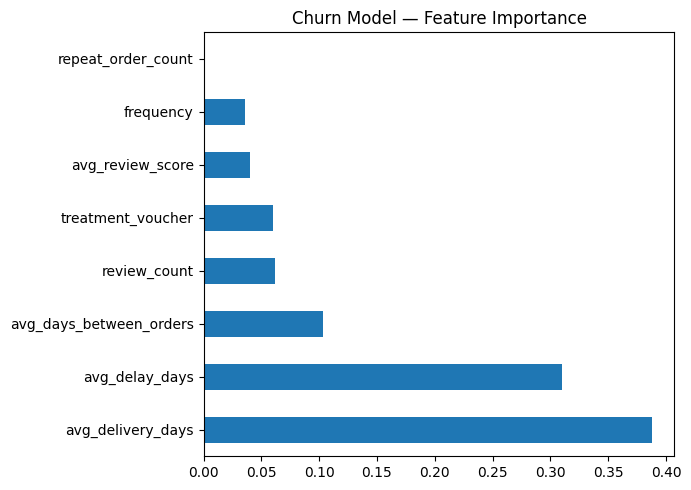

In [6]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

import matplotlib.pyplot as plt
importances.plot(kind="barh", figsize=(7,5), title="Churn Model — Feature Importance")
plt.tight_layout()
plt.show()

In [7]:
import joblib
joblib.dump(clf, "../models_churn.pkl")

['../models_churn.pkl']